---
title: Parameterized models
---

We can parameterize the edges to easily update the weights of the edge. We do this by assigning a coefficient vector to the edge instead of a rate. 

Once we have built the graph, we set the can set the model parameters using a vector of scalars with the same length as those assigned to the graph edges. This changes the weight of each edge to the inner sum of the edge vector and the parameter vector. E.g. if the state is `x1`, `x2` and the parameters are `p1`, `p2`, then the weight of the edge become `x1*p1+x2*p2`.

## Continuous phase-type distributions


To parameterize the ARG model above, we remove the keyword arguments `N` and `R`, assume their values are 1 so that the the coalescent rate is no longer a fixed rate 

`state[i]*(state[j]-same)/(1+same) / N`

but the a coefficient vector:

`[[state[i]*(state[j]-same)/(1+same), 0]`

Similarly the recombination rate is no longer `R` but `[0, 1]`.

A parameter vector of `[1/N, R]` will then produce the appropriate edge weights.

In [1]:
from phasic import Graph, with_ipv, StateIndexer, Property, set_log_level
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')


In [2]:
nr_samples = 4
indexer = StateIndexer(descendants=[
    Property('loc1', max_value=nr_samples),
    Property('loc2', max_value=nr_samples)
])

initial = [0] * indexer.state_length
initial[indexer.props_to_index(loc1=1, loc2=1)] = nr_samples

@with_ipv(initial)
def two_locus_arg_2param(state, indexer=None): # <- changed

    transitions = []
    if state.sum() <= 1: return transitions

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.index_to_props(i)

        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            pj = indexer.index_to_props(j)
            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            loc1 = pi.descendants.loc1 + pj.descendants.loc1
            loc2 = pi.descendants.loc2 + pj.descendants.loc2
            if loc1 <= nr_samples and loc2 <= nr_samples:
                child[indexer.props_to_index(loc1=loc1, loc2=loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]]) # <- changed

        if state[i] > 0 and pi.descendants.loc1 > 0 and pi.descendants.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.props_to_index(loc1=pi.descendants.loc1, loc2=0)] += 1
            child[indexer.props_to_index(loc1=0, loc2=pi.descendants.loc2)] += 1
            transitions.append([child, [0, 1]])                                 # <- changed

    return transitions


graph = Graph(two_locus_arg_2param, indexer=indexer) 

If you forget, you can get the number of parameters by calling:

In [3]:
# graph.param_length()

Having defined the graph with edge coefficients rather than fixed weights, we can now update the weights with specific parameter values and compute expectations. Here, we set the coalescence rate to \(1/N\) and the recombination rate to \(R\) and compute the expectation:

In [4]:
graph.update_weights([1/3, 5])
graph.expectation()

8.737764712303601

The new weights are computed as the the dot product of the edge coefficients and the vector of parameters passed to `update_weights` (parameters*coefficients). This covers most use cases, but for full flexibility you can pass a callback function `callback(parameters, coefficients) -> weight`. The example below is the same as the default behaviour:

In [5]:
graph.update_weights([1/3, 5], callback = lambda param, coef: np.sum(param * coef))
graph.expectation()

8.737764712303601

In [6]:
#| echo: false
if 'pytest' in sys.modules:
    graph.update_weights([1/3, 5])
    a = graph.expectation()
    graph.update_weights([1/3, 5], callback = lambda param, coef: np.sum(param * coef))
    b = graph.expectation()
    assert pytest.approx(a) == b

Now we can compute moments and distributions for different values of N and R without reconstructing the graph:

In [7]:
R_values = [1, 2, 1, 2, 1, 2]
N_values = [1, 1, 1.5, 1.5, 2, 2]

for N, R in zip(N_values, R_values):
    graph.update_weights([1/N, R])
    print(f'N:{N:<5} R:{R:<4} Mean: {graph.expectation():.4f}   Var:{graph.variance():.4f}')

N:1     R:1    Mean: 2.0091   Var:2.0644
N:1     R:2    Mean: 2.2949   Var:2.3298
N:1.5   R:1    Mean: 3.2565   Var:5.0349
N:1.5   R:2    Mean: 3.7032   Var:5.4038
N:2     R:1    Mean: 4.5897   Var:9.3192
N:2     R:2    Mean: 5.1655   Var:9.6597


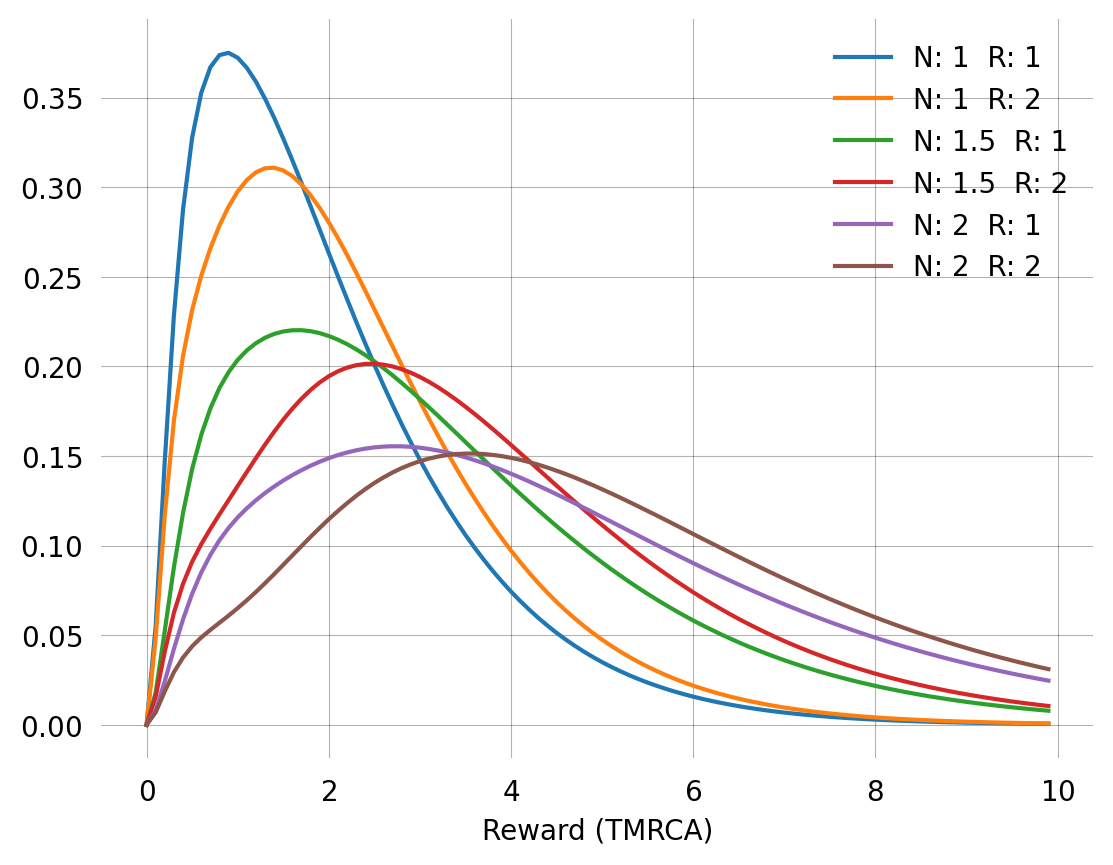

In [8]:
x = np.arange(0, 10, 0.1)
for N, R in zip(N_values, R_values):
    graph.update_weights([1/N, R])
    plt.plot(x, graph.pdf(x), label=f'N: {N}  R: {R}')
plt.xlabel('Reward (TMRCA)')
plt.legend()
plt.show()

When using the `callback` argument, the parameter vector can be shorter than the coefficient vectors. Just pass the `param_length` keyword argument to the `Graph` constructor. Allowing for more coefficients s handy if you need to pass more information to the callback function in order to update edge weights.

## Discrete phase-type distributions

Let us go back to the simpler coalescent model as an example of a discrete parameterized model.

Discrete rewards (indices of AUX vertices): [0 0 0 0 0 0 1 1 1 1]


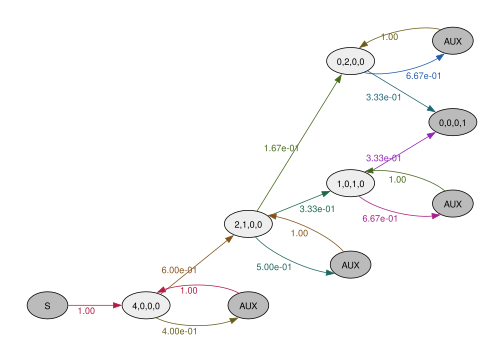

In [9]:
@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_2param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same), 0]))
    return transitions

mutation_graph = Graph(coalescent_2param)

def mutation_rate(state):
    nr_lineages = sum(state)
    return [0, nr_lineages]

# COMPOSABLE_MIGRATION: old call
# rewards = mutation_graph.discretize(mutation_rate)
mutation_graph = mutation_graph.discretize(mutation_rate)
rewards = mutation_graph.rewards

print("Discrete rewards (indices of AUX vertices):", rewards)
mutation_graph.plot()

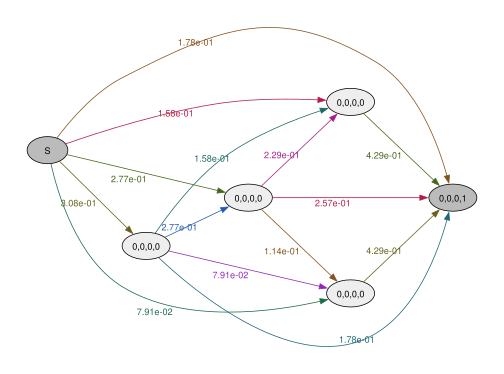

In [10]:
mutation_graph.update_weights([3, 2])
# COMPOSABLE_MIGRATION: old call
# rt_graph = mutation_graph.reward_transform(rewards)
rt_graph = mutation_graph.reward_transform(rewards)
rt_graph.plot()

In [11]:
mutation_graph.update_weights([3, 2])
# COMPOSABLE_MIGRATION: old call
# rt_graph = mutation_graph.reward_transform(rewards)
rt_graph = mutation_graph.reward_transform(mutation_graph.rewards)
rt_graph.pdf(2)

0.14830307025146516

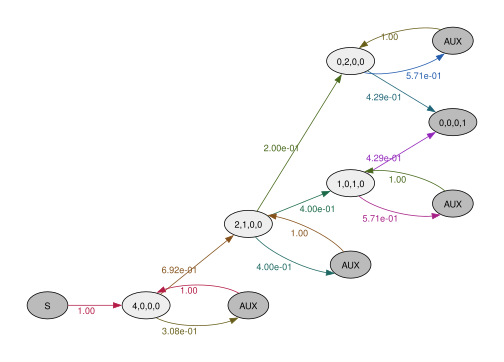

In [12]:
mutation_graph.plot()

In [13]:
rt_graph.expectation(), mutation_graph.expectation(mutation_graph.rewards)

(2.444444444444444, 2.444444444444444)

In [14]:
rt_graph.variance(), mutation_graph.variance(rewards)

(7.30864197530864, 4.864197530864198)

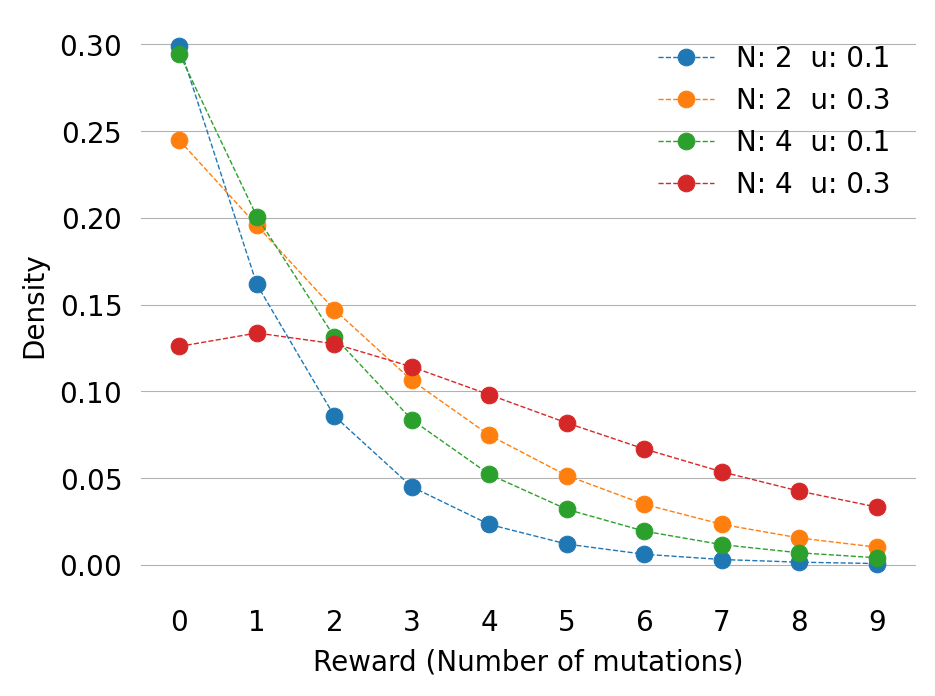

In [15]:
N_values = [2, 2, 4, 4, ]
u_values = [0.1, 0.3, 0.1, 0.3]
x = np.arange(0, 10, 1)
for N, u in zip(N_values, u_values):
    mutation_graph.update_weights([1/N, u])
    rt_graph = mutation_graph.reward_transform(rewards)
    sns.pointplot(x=x, y=rt_graph.pdf(x), label=f'N: {N}  u: {u}', 
                  linestyle='dashed', markers='o', 
                  markersize=6, linewidth=0.5)
plt.xlabel('Reward (Number of mutations)')
plt.ylabel('Density')
plt.legend()
plt.show()